# Split ring compound planetary gear design
Ce document vise à expliquer le principe de fonctionnement de ce type de train d'engrenages. Il propose une revue des équations et des conditions qui permettent de dimensionner de tels systèmes.

<div align="center">

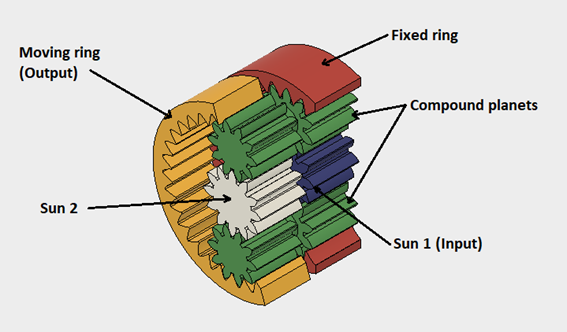

*Source : [Juan GG's blog](https://juangg-projects.blogspot.com/2018/02/split-ring-compound-epicyclicplanetary.html)*

</div>

Ce type de train particulier est le marriage entre un [train épicycloidale](https://fr.wikipedia.org/wiki/Train_%C3%A9picyclo%C3%AFdal) et un [réducteur harmonique](https://fr.wikipedia.org/wiki/Engrenage_%C3%A0_onde_de_d%C3%A9formation). Basé sur un assemblage de deux étages épicycloidaux, et sur une faible différence de nombre de dents entre les deux couronnes extérieures, le "SRCPG" permet, dans un volume très réduit d'obtenir de très gros ratios d'entraînement (~100 - 400) avec un encombrement très réduit. L'avantage comparé à un réducteur harmonique dans un contexte de construction amateur réside dans la simplicité de fabrication des pièces à l'aide d'une imprimante 3D (pas de pièces flexibles à concevoir, formes complexes adaptées à la fabrication adhésive...)

Voici quelques ressources complémentaires très utiles pour bien comprendre ce mécanisme :
- [Split Ring Compound Planet Epicyclic Gear](https://www.youtube.com/watch?v=-VtbSvVxaFA), David Hartkop et sa [feuille de calcul](https://docs.google.com/spreadsheets/d/1xrzSBmJ5qVQ8zQYUvLjdAsl90GyONrzupCxgUUP2wpk/edit?gid=297713819#gid=297713819) pour calculer les ratios 
- [Advanced Assembly of a Split-Ring Planetary Gearbox](https://www.youtube.com/watch?v=RwOQC_YCmg4), Pavel Surynek
- [Le composé planétaire à anneaux fendus - Ma réduction la plus élevée à ce jour](https://www.youtube.com/watch?v=4gkbb2CBzQI), Levi Janssen

---
## Équations (SRCPG / split-ring)

Ces informations sont basées sur le travail de David Hartkop mentionné plus haut, notamment de sa [feuille de calcul](https://docs.google.com/spreadsheets/d/1xrzSBmJ5qVQ8zQYUvLjdAsl90GyONrzupCxgUUP2wpk/edit?gid=297713819#gid=297713819) qui pemet de calculer le ratio d'entraînement à partir s'un ensemble de paramètres de base. 

Nous utilisons le schéma suivant pour paramétrer notre mécanisme :

![Schéma de paramétrage du mécanisme](schema_global_SRCPG.png)


| Élément | Formule | Pourquoi (intuition / raison) |
|---|---|---|
| Géométrie étage 1 | `Zp,f = (Zf - Zs) / 2` (doit être entier) | En engrènement interne, la couronne vérifie typiquement `Zf = Zs + 2·Zp,f` : c'est la contrainte d'entraxe (Diametre externe = Diametre soleil + 2 planetes). |
| Lien des deux dentures planète | `Zp_o = Zp_f · n` (Np2 et Np1 doivent être entiers)| On ajoute un facteur n entre les deux étages de la planète composée pour se donner plus de liberté sur la valeur finale du rapport d'entraînement. Np1 et Np2 doivent être entiers puisqu'il s'agit de nombres de dents.  |
| Couronne étage 2 | `Zo = n·Zf + P` | C'est le "truc" du split-ring : on force un **petit écart** de dents (lié à `P`) entre couronnes, ce qui crée un mouvement relatif très lent entre les couronnes et donc un **gros ratio**. |
| Soleil étage 2 | `Zs2 = Zo - 2·Zp,o` | Même raison que l'étage 1 : assurer l'entraxe interne correct sur l'étage 2 (`Zo = Zs2 + 2·Zp,o`). |
| Ajustement du module | `m2 = m1 · (Zf - Zp,f) / (Zo - Zp,o)` (module en mm/dent) | Sert à faire cohabiter deux dentures différentes **sur le même axe de planète** : on choisit `m2` pour que le rayon de trajectoire des planètes (carrier) soit cohérent sur les deux engrènements. |
| Ratio étage 1 | `R1 = (Zf) / Zs1) + 1` | Résultat cinématique standard d'un train épicycloïdal à couronne fixe.|
| Ratio étage 2 | `R2 = (n·Zf) / (Zo - n·Zf)` | Amplification "différentielle" due au faible écart de dents entre `Zo` et `n·Zf`. Si cet écart est petit, `R2` devient très grand.------------- |
| Ratio final | `Rf = R1 · R2` | Les deux effets se multiplient : étage 1 "pré-réduit", étage 2 "différentiel lent". |

<br>

| Élément | condition | Pourquoi (intuition / raison) |
|---|---|---|
| Validité `Zp,f` | `(Zf - Zs)` pair | Si le résultat n'est pas pair, Np1 ne peut être entier. Or c'est impossible pour un nombre de dents (donc `n`doit être rationnel).|
| Nombres de dents divisibles par P | Ex: `Zs % P == 0`, `Zf % P == 0`, `Zs2 % P == 0` | Condition qui impose que les planètes sont équiréparties et que les deux étages des planètes composées ne sont pas déphasées (=P planètes identiques, montables à intervalles réguliers). |
| Anti-collision planètes | `2·a·sin(π/P) ≥ 2·R_planète + marge` | Vérifie que les centres des planètes sont assez éloignés pour que les corps (et non seulement les dents) ne se touchent pas. |
| Encombrement | `Ø_ext ≈ Ø_primitif(anneau) + 2·addendum` | Approximation rapide : sera affiné en CAO, mais ce filtre évite d'explorer des configurations qui ne rentreront jamais. |
| Min dents | `Z >= 17` (valeur par défaut, paramétrable) | Sous un certain nombre de dents, risque d'entaille de pied / sous-denture (undercut) et fragilité des dents. |

Les équations ci-dessus sont implémentées dans le code de recherche de designs valides présenté plus loin.

## Script de paramétrisation
Le script *SRCPG.py* implémente une classe `SRCPGDesigner` qui permet de trouver, pour quelques contraintes données, les combinaisons possibles pour réaliser un SRCPG basé sur les équations de dimensionnement inspirées du travail de David Hartkop.

Les paramètres d'entrée sont les suivants :
- `max_diameter` [mm] : Diamètre extérieur maximum autorisé pour le système (contrainte d'encombrement).
- `module_stage1` [mm/dent] : Module des engrenages pour le premier étage (étage d'entrée).
- `target_ratio` : Ratio de réduction cible (ex. 120 pour une réduction de 120:1).
- `ratio_tolerance` : Tolérance relative sur le ratio atteint (ex. 0.1 pour ±10%).
- `num_planets` (P) : Nombre de planètes (satellites) dans le système (typiquement 3 ou 4).
- `n_values` : Liste de valeurs pour le multiplicateur n (rapport entre les dentures des planètes, souvent [1.0]).
- `min_teeth` : Nombre minimum de dents pour chaque engrenage (par défaut 17, évite les problèmes de sous-denture).
- `planet_clearance_factor` : Facteur de marge pour éviter les collisions entre planètes (ex. 1.10 pour 10% de marge).

In [4]:
import sys
sys.path.append('../utils')

# Important: si SRCPG.py a été modifié, le kernel peut garder une ancienne version.
# On force un reload pour éviter "cannot import name ..." après édition.
import importlib
import SRCPG
importlib.reload(SRCPG)

from SRCPG import SRCPGConstraints, SRCPGDesigner
from tqdm import tqdm  # Assurer que tqdm est importé

constraints = SRCPGConstraints(
    max_diameter=150,      # mm (approx)
    module_stage1=0.5,    # mm/dent (étage 1)
    target_ratio=120.0,
    ratio_tolerance=0.1,  # ±10%
    num_planets=3,
    n_values=(1.0, 3/2, 2.0),  # n du tableur (plusieurs valeurs pour ralentir)
    planet_clearance_factor=1.10,
)

designer = SRCPGDesigner(constraints)
solutions = designer.search()

designer.print_solutions(10)
if solutions:
    best = solutions[0]
    print(
        f"\n📊 Meilleure solution: Rf={best.rf:.2f} (R1={best.r1:.2f}, R2={best.r2:.2f}), "
        f"Ø≈{best.approx_overall_diameter_mm:.1f}mm, "
        f"Zs/Zf/Zp,f={best.zs}/{best.zf}/{best.zpf}, "
        f"Zs2/Zo/Zp,o={best.zs2}/{best.zo}/{best.zpo}, "
        f"m2={best.module_stage2:.2f}mm, n={best.n:.1f}"
    )
else:
    print("❌ Aucune solution trouvée")

Recherche SRCPG: 100%|██████████| 64/64 [00:00<00:00, 441.90it/s]


✅ SRCPG: 54 solutions (ratio≈120.0 ±10%)
✅ 54 solutions SRCPG trouvées!

  # |   Zs |   Zf | Zp,f ||  Zs2 |   Zo | Zp,o ||     m1 |     m2 |         Rf |       Ø~ |     n
--------------------------------------------------------------------------------------------------------------
  1 |   18 |   72 |   27 ||   21 |   75 |   27 ||   0.50 |   0.47 |     120.00 |    37.0mm |   1.0
  2 |   30 |   90 |   30 ||   33 |   93 |   30 ||   0.50 |   0.48 |     120.00 |    46.0mm |   1.0
  3 |   60 |  120 |   30 ||   63 |  123 |   30 ||   0.50 |   0.48 |     120.00 |    61.0mm |   1.0
  4 |   54 |   90 |   18 ||   84 |  138 |   27 ||   0.50 |   0.32 |     120.00 |    46.0mm |   1.5
  5 |   57 |  117 |   30 ||   60 |  120 |   30 ||   0.50 |   0.48 |     119.05 |    59.5mm |   1.0
  6 |   63 |  123 |   30 ||   66 |  126 |   30 ||   0.50 |   0.48 |     121.05 |    62.5mm |   1.0
  7 |   78 |  132 |   27 ||   81 |  135 |   27 ||   0.50 |   0.49 |     118.46 |    67.0mm |   1.0
  8 |   33 |   93 |   30

## Assemblage et fabrication

### Ordre d’assemblage typique

1. Monter les roulements principaux (axe Soleil, axe porte-satellites).
2. Monter le Soleil $S$ sur l’arbre moteur (type NEMA17) et vérifier son faux-rond.
3. Monter les planètes sur le porte-satellites $C$ (axes, vis, entretoises).
4. Introduire l’ensemble $C + P$ dans la couronne fixe $F$.
5. Ajouter ensuite la couronne de sortie $O$ (split-ring), puis refermer le carter / les flasques.

### Jeux (impression 3D FDM, valeurs indicatives)

- Jeu radial entre dents en prise : $j_{dents} \approx 0{,}15$ à $0{,}20\,\text{mm}$
- Jeu radial entre corps de planètes et carter : $0{,}20$ à $0{,}30\,\text{mm}$
- Jeu axial (empilement d’épaisseurs) : $0{,}15$ à $0{,}30\,\text{mm}$ par face en contact

### Vérifications manuelles à l’assemblage

- Le train doit pouvoir tourner à la main sans point dur dès que toutes les pièces sont emboîtées (moteur déconnecté).
- En faisant tourner le Soleil d’un tour complet, aucune planète ne doit heurter une nervure, vis ou élément du carter.
- Un léger backlash en sortie doit exister, sans saut de dents sous une légère charge à la main.


---

## Remarques fabrication (épaisseurs, impression)

- Épaisseur minimale de paroi et de dent : **au moins $2\times$ le diamètre de buse** (règle pratique FDM).
- Les valeurs de jeux (radial/axial) sont indicatives : à recalibrer en fonction du matériau (PLA/PETG), du débit, de la ventilation et de la précision dimensionnelle de l’imprimante.

<style>
body {
  font-family: system-ui, sans-serif;
  line-height: 1.6;
}

h1, h2 {
  color: #1a2a3a;
}

table {
  width: 100%;
  border-collapse: collapse;
}

th, td {
  border: 1px solid #ccc;
  padding: 6px;
}

.info-box {
  background: #eef6ff;
  border-left: 6px solid #2a7fff;
  padding: 1em;
  margin: 1em 0;
}
</style>
